In [3]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt

# 1. Download Stock Data
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2024-01-01")

# FIX: If yfinance returns MultiIndex columns, flatten them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Ensure data is clean
df = df.dropna()
print(f"Data for {ticker} cleaned and loaded!")
df.head()

[*********************100%***********************]  1 of 1 completed

Data for AAPL cleaned and loaded!


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696617,72.455935,71.472439,71.629122,146322800
2020-01-06,72.267960,72.306529,70.568532,70.819231,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [4]:
# 1. Simple Moving Averages (SMA)
df['SMA_20'] = ta.sma(df['Close'], length=20)
df['SMA_50'] = ta.sma(df['Close'], length=50)

# 2. Relative Strength Index (RSI)
df['RSI_14'] = ta.rsi(df['Close'], length=14)

# 3. Moving Average Convergence Divergence (MACD)
# We calculate it as a separate dataframe
macd_df = ta.macd(df['Close'], fast=12, slow=26, signal=9)

# Join only if macd_df is not None
if macd_df is not None:
    df = pd.concat([df, macd_df], axis=1)
    print("Indicators Calculated Successfully!")
else:
    print("Error: MACD calculation failed. Ensure you have enough data points.")

display(df.tail())

Indicators Calculated Successfully!


,Close,High,Low,Open,Volume,SMA_20,SMA_50,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
Date,,,,,,,,,,,
2023-12-22,191.609467,193.400854,190.985939,193.173208,37149600,191.677262,183.401251,54.672773,2.630679,-0.601551,3.232230
2023-12-26,191.065125,191.896484,190.847385,191.619364,28919300,191.838587,183.686989,53.090026,2.302596,-0.743707,3.046304
2023-12-27,191.164108,191.510516,189.125291,190.510906,48087700,191.974674,183.977276,53.354466,2.027207,-0.815277,2.842484
2023-12-28,191.589676,192.658574,191.183888,192.143916,34049900,192.183010,184.307111,54.540976,1.822293,-0.816153,2.638446
2023-12-29,190.550461,192.401229,189.758683,191.906370,42672100,192.310683,184.642058,51.121301,1.558080,-0.864293,2.422373


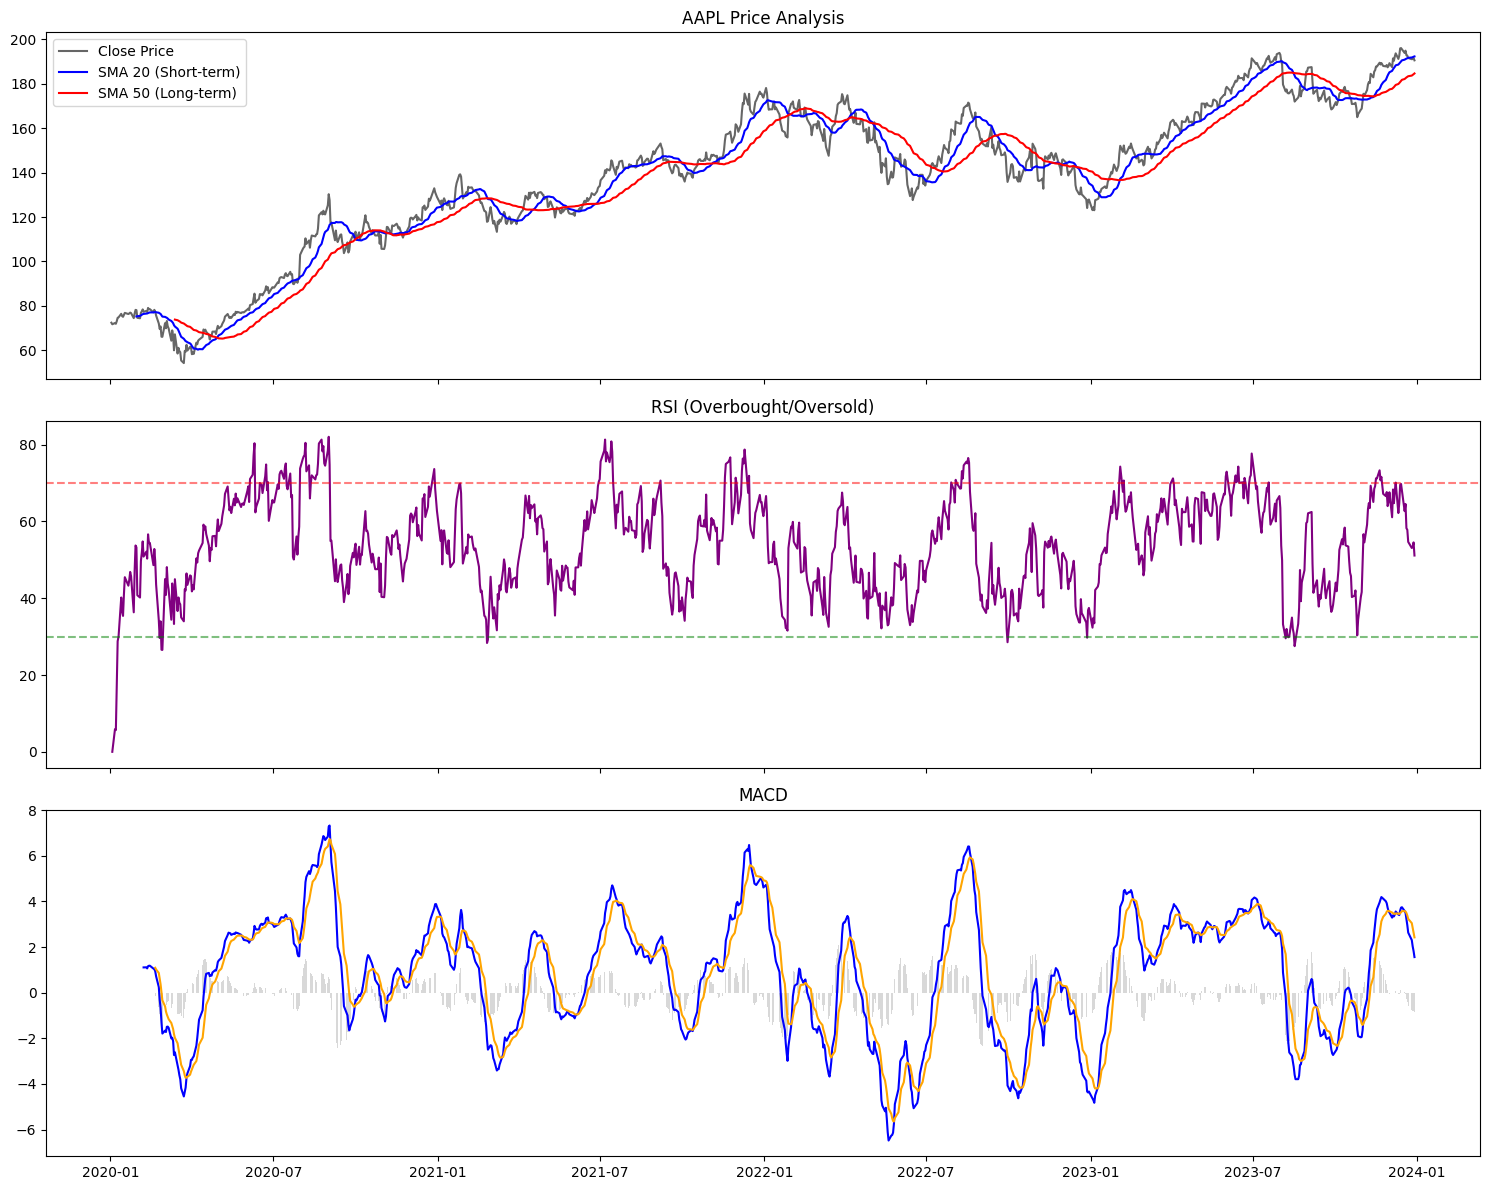

In [5]:
# Create a figure with 3 subplots (Price, RSI, MACD)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Panel 1: Price and Moving Averages
ax1.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.6)
ax1.plot(df.index, df['SMA_20'], label='SMA 20 (Short-term)', color='blue')
ax1.plot(df.index, df['SMA_50'], label='SMA 50 (Long-term)', color='red')
ax1.set_title(f'{ticker} Price Analysis')
ax1.legend()

# Panel 2: RSI (Momentum)
ax2.plot(df.index, df['RSI_14'], label='RSI', color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5) # Overbought line
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold line
ax2.set_title('RSI (Overbought/Oversold)')

# Panel 3: MACD (Trend Momentum)
ax3.plot(df.index, df['MACD_12_26_9'], label='MACD Line', color='blue')
ax3.plot(df.index, df['MACDs_12_26_9'], label='Signal Line', color='orange')
ax3.bar(df.index, df['MACDh_12_26_9'], label='Histogram', color='gray', alpha=0.3)
ax3.set_title('MACD')

plt.tight_layout()
plt.show()